# Implementing ANNs with TensorFlow - Homework 05 (Group 4)

## Assignment: CIFAR-10 Classification

### Preparing the data set

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling ~/tensorflow_datasets/cifar10/3.0.2.incompleteKPJ231/cifar10-train.tfrecord*...:   0%|          | 0/…

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling ~/tensorflow_datasets/cifar10/3.0.2.incompleteKPJ231/cifar10-test.tfrecord*...:   0%|          | 0/1…

Dataset cifar10 downloaded and prepared to ~/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


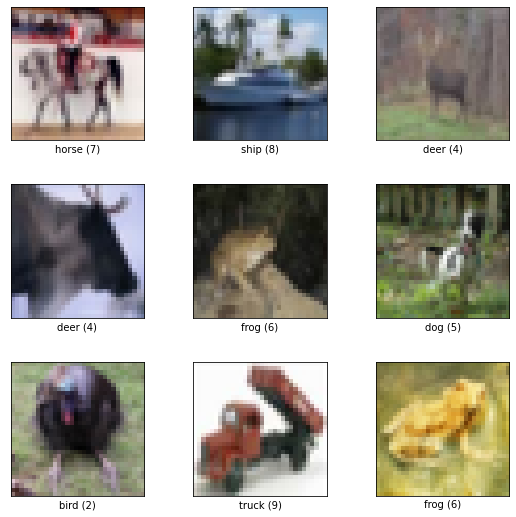

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

# load the data
(train_ds, test_ds), ds_info = tfds.load("cifar10", split=["train", "test"], as_supervised=True, with_info=True)
# inspect the data: images of shape (32, 32, 3) representing ten non-overlapping classes
tfds.show_examples(train_ds, ds_info)
# take only a subset of the data to speed up the training process
train_ds = train_ds.take(10000)
test_ds = test_ds.take(1000)

In [2]:
def prepare_data(cifar_10, batch_size=32):
  """
  This function is used to prepare the raw data for training and testing.

  Arguments:
  cifar_10 -- (a subset of) the CIFAR-10 dataset
  batch_size -- denotes the batch size (default is 32)
  """
  # convert images to float32 data type
  cifar_10 = cifar_10.map(lambda img, target: (tf.cast(img, tf.float32), target))
  # normalize the data by projecting the pixel values into range [-1, 1]
  cifar_10 = cifar_10.map(lambda img, target: (tf.cast(tf.image.per_image_standardization(img), tf.float32), target))
  # represent targets as one-hot vectors (depth=10 as there are ten possible classifications)
  cifar_10 = cifar_10.map(lambda img, target: (img, tf.one_hot(target, depth=10)))

  # cache progress into memory
  cifar_10 = cifar_10.cache()
  # shuffle the data into a random order
  cifar_10 = cifar_10.shuffle(1000)
  # use batches of a given size
  cifar_10 = cifar_10.batch(batch_size)
  # prefetch some data points
  cifar_10 = cifar_10.prefetch(tf.data.AUTOTUNE)

  return cifar_10

# transform the training and test data
train_dataset = train_ds.apply(prepare_data)
test_dataset = test_ds.apply(prepare_data)

### The CNN model

In [3]:
class ConvModel(tf.keras.Model):
  """
  This subclass of the keras model builds our neural network.
  """
  def __init__ (self, layer_config, optimizer):
    """
    The constructor initiates the layers and their activation functions.

    Arguments:
    layer_config -- a list of convolutional and pooling layers
    optimizer -- denotes the model optimizer
    """
    # call the parent constructor
    super().__init__()
    # use categorical crossentropy loss since the data holds more than two classes
    self.loss_function = tf.keras.losses.CategoricalCrossentropy()
    # use Adam as our optimizer
    self.optimizer = optimizer
    # instantiate the layers according to a given architecture
    self.conv_layers = layer_config
    # instantiate the output layer with softmax as activation function
    self.output_layer = tf.keras.layers.Dense(10, activation=tf.nn.softmax)
    # instantiate metric objects to keep track of the training/test loss and accuracy
    self.loss_metric = tf.keras.metrics.Mean(name="loss") 
    self.accuracy_metric = tf.keras.metrics.CategoricalAccuracy(name="accuracy")

  @tf.function
  def call (self, input):
    """
    This function calls the model on new input and returns the output as tensors.

    Arguments:
    input -- denotes the input tensors
    """
    # feed the input through the network
    output = self.conv_layers[0](input)
    for layer in self.conv_layers[1:]:
      output = layer(output)
    output = self.output_layer(output)

    return output

  def reset_metrics(self):
    """
    This function will reset the metric objects after every training epoch.
    """
    self.loss_metric.reset_states()
    self.accuracy_metric.reset_states()

  @tf.function
  def train_step(self, input):
    """
    This function defines a step during the training process
    Updates and returns the loss and accuracy metrics after the training step.

    Arguments:
    input -- the input tensors (img, target) to the model
    """
    img, target = input
    with tf.GradientTape() as tape:
      # create the prediction
      prediction = self(img, training=True)
      # calculate the loss with an additional regularization term
      loss = self.loss_function(target, prediction) + tf.reduce_sum(self.losses)
    # calculate the gradients
    gradients = tape.gradient(loss, model.trainable_variables)
    # apply the gradients
    self.optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    # update the metrics
    self.loss_metric.update_state(loss)
    self.accuracy_metric.update_state(target, prediction)

    #return {metric.name: metric.result() for metric in self.metrics}
    return self.loss_metric.result(), self.accuracy_metric.result()

  @tf.function
  def test(self, test_data):
    """
    A function to test how the model performs on the given data.
    Returns the loss and accuracy metrics.

    Arguments:
    test_data -- the data used for testing
    """
    # unpack the the test data
    img, target = test_data
    # create prediction but do not backpropagate
    prediction = self(img, training=False)
    # calculate loss
    loss = self.loss_function(target, prediction) + tf.reduce_sum(self.losses) 
    # update the metrics
    self.loss_metric.update_state(loss)
    self.accuracy_metric.update_state(target, prediction)

    #return {metric.name: metric.result() for metric in self.metrics}
    return self.loss_metric.result(), self.accuracy_metric.result()

### Training the network

In [6]:
def training(model, n_epochs):
  """
  Defines the training process of our neural network.
  Returns the training losses and accuracies.

  Arguments:
  model -- the model object representing our neural network
  n_epochs -- the number of training steps
  """
  # lists to track training/test losses and accuracies
  train_losses = []
  train_accuracies = []
  test_losses = []
  test_accuracies = []

  # check how our model performs on training data before training
  for data in train_dataset:
    train_loss, train_accuracy = model.test(data)
  train_losses.append(train_loss)
  train_accuracies.append(train_accuracy)
  
  model.reset_metrics()
  
  # check how our model performs on test data before training
  for data in test_dataset:
    test_loss, test_accuracy = model.test(data)
  test_losses.append(test_loss)
  test_accuracies.append(test_accuracy)

  model.reset_metrics()

  print("Training progress: \n")

  # train for given number of epochs
  for epoch in range(n_epochs):
    # print the accuracy after the current epoch
    print(f'Epoch {str(epoch)} started with accuracy {test_accuracies[-1]}')

    # train the network
    for data in train_dataset:
      train_loss, train_accuracy = model.train_step(data)
    # store training loss and accuracy
    train_losses.append(train_loss.numpy())
    train_accuracies.append(train_accuracy.numpy())

    # reset the model metrics
    model.reset_metrics()

    # test the network
    for data in test_dataset:
      test_loss, test_accuracy = model.test(data)
    # store test loss and accuracy
    test_losses.append(test_loss.numpy())
    test_accuracies.append(test_accuracy.numpy())

    # again reset the model metrics
    model.reset_metrics()

  return train_losses, train_accuracies, test_losses, test_accuracies

In [7]:
tf.keras.backend.clear_session()
# hyperparameters for the training process
# train for 15 epochs
num_epochs = 15
# base model (taken from lecture material)
layers = [tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu"), 
          tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu"),
          tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),
          tf.keras.layers.Conv2D(filters=48, kernel_size=3, padding="same", activation="relu"),
          tf.keras.layers.Conv2D(filters=48, kernel_size=3, padding="same", activation="relu"),
          tf.keras.layers.GlobalAvgPool2D()]
# use Adam optimizer
optimizer = tf.keras.optimizers.Adam()
# instantiate the model
model = ConvModel(layer_config=layers, optimizer=optimizer)
# train the base model
train_losses, train_accuracies, test_losses, test_accuracies = training(model, num_epochs)

Training progress: 

Epoch 0 started with accuracy 0.12999999523162842
Epoch 1 started with accuracy 0.26499998569488525
Epoch 2 started with accuracy 0.4020000100135803
Epoch 3 started with accuracy 0.4059999883174896
Epoch 4 started with accuracy 0.47200000286102295
Epoch 5 started with accuracy 0.5189999938011169
Epoch 6 started with accuracy 0.5389999747276306
Epoch 7 started with accuracy 0.5320000052452087
Epoch 8 started with accuracy 0.5569999814033508
Epoch 9 started with accuracy 0.5899999737739563
Epoch 10 started with accuracy 0.5680000185966492
Epoch 11 started with accuracy 0.5770000219345093
Epoch 12 started with accuracy 0.597000002861023
Epoch 13 started with accuracy 0.5889999866485596
Epoch 14 started with accuracy 0.5830000042915344


### Visualization

In [8]:
def visualization(train_losses, train_accuracies, test_losses, test_accuracies):
  """
  This function visualizes the training progress by showing the mean losses and accuracies after each epoch.

  Arguments:
  train_losses -- denotes the recorded losses during training
  train_accuracies -- accuracies during training
  test_losses -- losses during the test stage
  test_accuracies -- accuracies during testing
  """
  # create the plot grid
  fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(9,6))
  # plot training and test losses and accuracies
  line1, = axes[0].plot(train_losses, color="orange")
  line2, = axes[0].plot(test_losses, color="green")
  line3, = axes[1].plot(train_accuracies, color="orange")
  line4, = axes[1].plot(test_accuracies, color="green")
  # set the axis limits and labels
  axes[0].set(ylabel="Loss")
  axes[1].set(ylim=[0, 1], xlabel="Training steps", ylabel="Accuracy")
  # create the legend
  axes[0].legend((line1, line2), ("Training","Test"))

  fig.suptitle("Training Progress")

  plt.show()

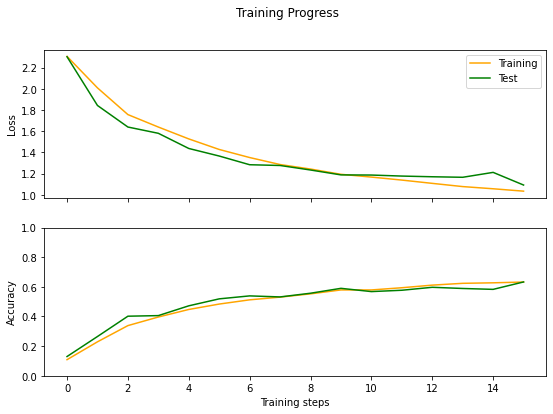

In [9]:
# visualize the training progress of the model
visualization(train_losses, train_accuracies, test_losses, test_accuracies)

**Remarks:**

We can see that the base model performs relatively poorly on both the training and test data, approaching only an accuracy of circa 60%. However, we only a subset of the training and test data.

### Adjusting hyperparameters and architecture

#### Variation 1: Modulate filter & kernel sizes and add another Dense layer

Training progress: 

Epoch 0 started with accuracy 0.09200000017881393
Epoch 1 started with accuracy 0.37599998712539673
Epoch 2 started with accuracy 0.4390000104904175
Epoch 3 started with accuracy 0.4690000116825104
Epoch 4 started with accuracy 0.48399999737739563
Epoch 5 started with accuracy 0.5009999871253967
Epoch 6 started with accuracy 0.5040000081062317
Epoch 7 started with accuracy 0.5090000033378601
Epoch 8 started with accuracy 0.5199999809265137
Epoch 9 started with accuracy 0.5199999809265137
Epoch 10 started with accuracy 0.5299999713897705
Epoch 11 started with accuracy 0.5180000066757202
Epoch 12 started with accuracy 0.5320000052452087
Epoch 13 started with accuracy 0.5379999876022339
Epoch 14 started with accuracy 0.5379999876022339


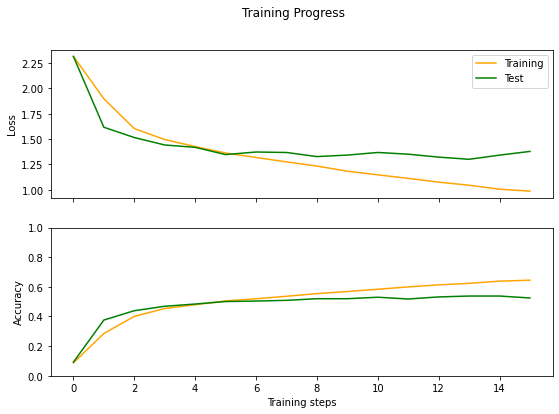

In [10]:
# conv2D (no padding) -> maxpool -> conv2D with bigger kernel size -> maxpool -> conv2D -> flatten -> dense 
layers = [tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu"), 
          tf.keras.layers.MaxPooling2D(pool_size=2),
          tf.keras.layers.Conv2D(filters=64, kernel_size=5, activation="relu"),
          tf.keras.layers.MaxPooling2D(pool_size=3),
          tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu"),
          tf.keras.layers.Flatten(),
          tf.keras.layers.Dense(64, activation="relu")]

# create and train model, then visualize the results
model = ConvModel(layer_config=layers, optimizer=optimizer)
train_losses, train_accuracies, test_losses, test_accuracies = training(model, num_epochs)
visualization(train_losses, train_accuracies, test_losses, test_accuracies)

**Remarks:**

This model does not show any improvement regarding the accuracy, finishing even lower at about 54%.

#### Variation 2: Use batch normalisation

Training progress: 

Epoch 0 started with accuracy 0.10400000214576721
Epoch 1 started with accuracy 0.12099999934434891
Epoch 2 started with accuracy 0.09300000220537186
Epoch 3 started with accuracy 0.12099999934434891
Epoch 4 started with accuracy 0.12099999934434891
Epoch 5 started with accuracy 0.10400000214576721
Epoch 6 started with accuracy 0.1120000034570694
Epoch 7 started with accuracy 0.1120000034570694
Epoch 8 started with accuracy 0.10400000214576721
Epoch 9 started with accuracy 0.10000000149011612
Epoch 10 started with accuracy 0.1120000034570694
Epoch 11 started with accuracy 0.1120000034570694
Epoch 12 started with accuracy 0.09300000220537186
Epoch 13 started with accuracy 0.09300000220537186
Epoch 14 started with accuracy 0.1120000034570694


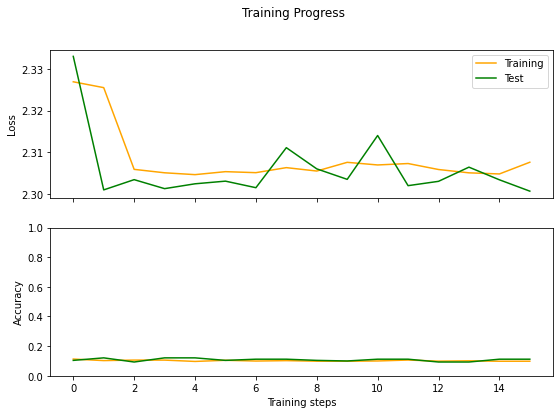

In [11]:
# architecture similar to the one used in the regularization script
layers = [tf.keras.layers.Conv2D(32, 3, activation="relu"), 
          tf.keras.layers.BatchNormalization(),
          tf.keras.layers.Conv2D(32, 3, activation="relu"), 
          tf.keras.layers.BatchNormalization(),
          tf.keras.layers.Conv2D(32, 3, activation="relu"), 
          tf.keras.layers.BatchNormalization(),
          tf.keras.layers.Conv2D(32, 3, activation="relu"), 
          tf.keras.layers.BatchNormalization(),
          tf.keras.layers.Flatten()]

# create and train model, then visualize the results
model = ConvModel(layer_config=layers, optimizer=optimizer)
train_losses, train_accuracies, test_losses, test_accuracies = training(model, num_epochs)
visualization(train_losses, train_accuracies, test_losses, test_accuracies)

**Remarks:**

Well, this model performs quite terribly, as we barely exceed 10% accuracy on the training and test data. As we are severly underfitting, there must be big problems with the model structure.